In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df_hazard1  = pd.read_excel("/content/pricing_equipment_failure (2).xlsx", sheet_name = "segment_summary")

In [ ]:
df_hazard1

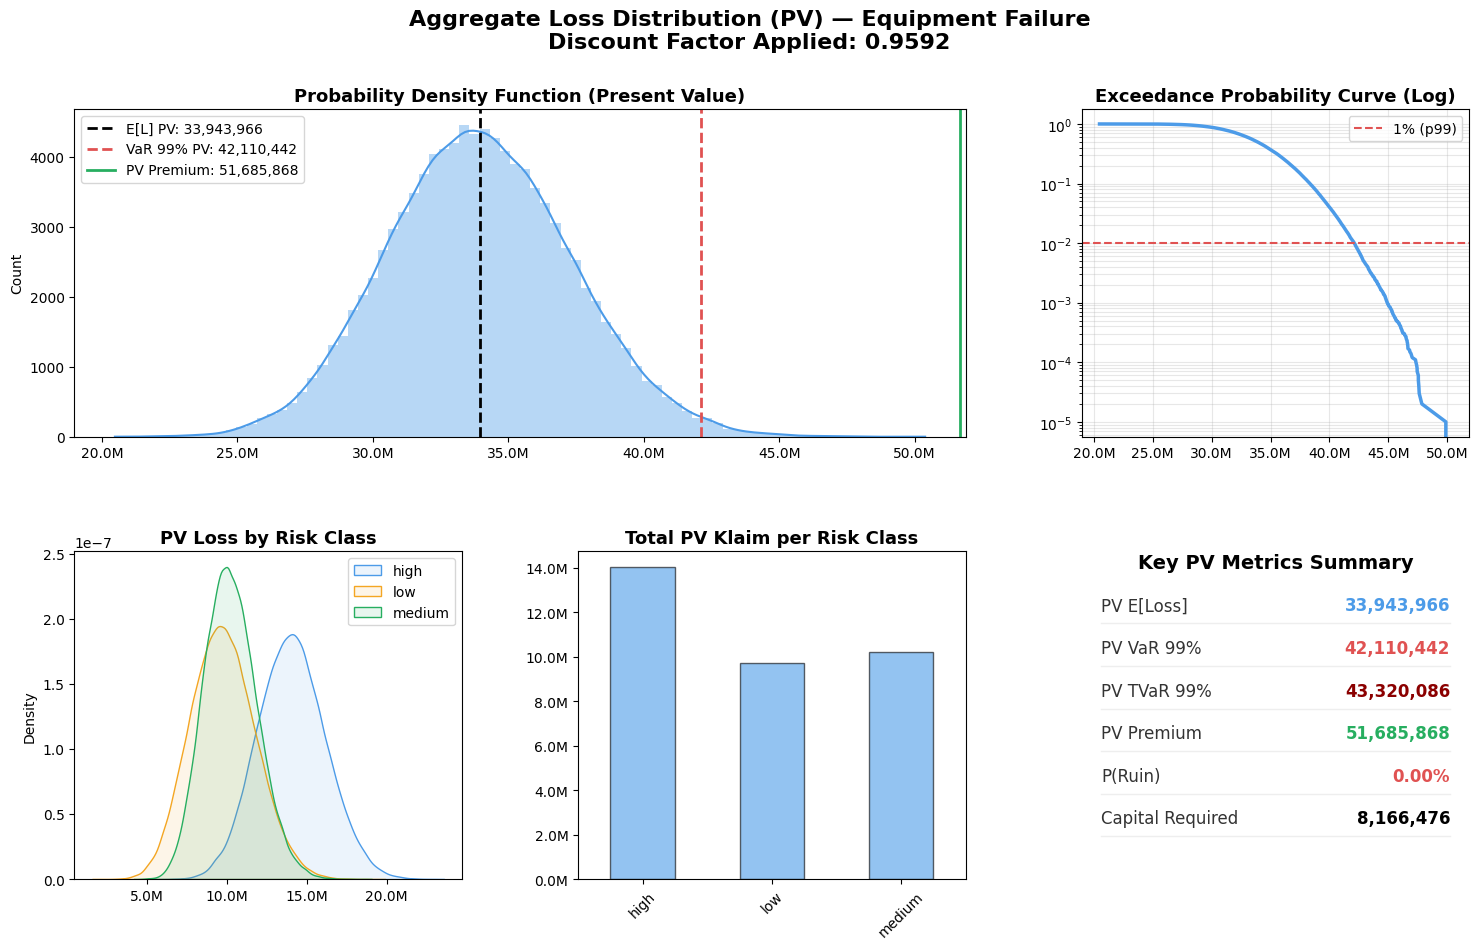

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# 1. KONFIGURASI & INPUT DATA
# =============================================================================
HAZARD_NAME = "Equipment Failure" # Sesuaikan nama hazard
N_SIM       = 100_000
SEED        = 42
np.random.seed(SEED)

# Masukkan Discount Factor hasil perhitungan yield curve/risk-free rate
# Contoh: Jika menggunakan risk-free rate untuk tahun 2190
DISCOUNT_FACTOR_2190 = 0.959166

# =============================================================================
# 2. BOOTSTRAP SIMULATION (LOGIKA PV)
# =============================================================================
# Mengambil nilai klaim (nominal)
klaim_values = df_hazard1['Klaim'].values
n_groups     = len(klaim_values)

# Bootstrap Aggregate Portfolio (Nominal)
agg_losses_nominal = np.array([
    np.random.choice(klaim_values, size=n_groups, replace=True).sum()
    for _ in range(N_SIM)
])

# KONVERSI KE PRESENT VALUE (PV)
agg_losses_pv = agg_losses_nominal * DISCOUNT_FACTOR_2190

# Bootstrap per risk_class (PV) untuk grafik breakdown
seg_losses_pv = {}
for rc in sorted(df_hazard1['risk_class'].unique()):
    vals = df_hazard1[df_hazard1['risk_class'] == rc]['Klaim'].values
    n    = len(vals)
    seg_losses_pv[rc] = np.array([
        np.random.choice(vals, size=n, replace=True).sum()
        for _ in range(N_SIM)
    ]) * DISCOUNT_FACTOR_2190

# =============================================================================
# 3. PERHITUNGAN METRIK (PV)
# =============================================================================
total_premi_pv = df_hazard1['Earned Premium'].sum() * DISCOUNT_FACTOR_2190

mean_loss_pv = agg_losses_pv.mean()
p99_pv       = np.percentile(agg_losses_pv, 99)
tvar99_pv    = agg_losses_pv[agg_losses_pv >= p99_pv].mean()
prob_ruin    = (agg_losses_pv > total_premi_pv).mean()
req_capital  = p99_pv - mean_loss_pv

# =============================================================================
# 4. VISUALISASI (DISET AGAR MIRIP GAMBAR TARGET)
# =============================================================================
BLUE, RED, GREEN, ORANGE, PURPLE = '#4C9BE8', '#E05252', '#27AE60', '#F4A623', '#9B59B6'

fig = plt.figure(figsize=(18, 10))
fig.suptitle(f"Aggregate Loss Distribution (PV) — {HAZARD_NAME}\n"
             f"Discount Factor Applied: {DISCOUNT_FACTOR_2190:.4f}",
             fontsize=16, fontweight='bold', y=0.98)

# Grid Layout: 2 baris, 3 kolom
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)
fmt = plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')

# --- Plot 1: PDF Aggregate Loss ---
ax1 = fig.add_subplot(gs[0, :2])
sns.histplot(agg_losses_pv, bins=80, kde=True, ax=ax1, color=BLUE, alpha=0.4, edgecolor='none')
ax1.axvline(mean_loss_pv, color='black', lw=2, ls='--', label=f'E[L] PV: {mean_loss_pv:,.0f}')
ax1.axvline(p99_pv, color=RED, lw=2, ls='--', label=f'VaR 99% PV: {p99_pv:,.0f}')
ax1.axvline(total_premi_pv, color=GREEN, lw=2, label=f'PV Premium: {total_premi_pv:,.0f}')
ax1.set_title('Probability Density Function (Present Value)', fontsize=13, fontweight='bold')
ax1.xaxis.set_major_formatter(fmt)
ax1.set_ylabel('Count')
ax1.legend(loc='upper left')

# --- Plot 2: Exceedance Probability (Log Scale) ---
ax2 = fig.add_subplot(gs[0, 2])
sorted_pv = np.sort(agg_losses_pv)
survival = 1 - np.arange(1, len(sorted_pv) + 1) / len(sorted_pv)
ax2.plot(sorted_pv, survival, color=BLUE, lw=2.5)
ax2.axhline(0.01, color=RED, ls='--', label='1% (p99)')
ax2.set_yscale('log')
ax2.set_title('Exceedance Probability Curve (Log)', fontsize=13, fontweight='bold')
ax2.xaxis.set_major_formatter(fmt)
ax2.grid(True, alpha=0.3, which='both')
ax2.legend()

# --- Plot 3: Distribution per Risk Class (KDE) ---
ax3 = fig.add_subplot(gs[1, 0])
colors_list = [BLUE, ORANGE, GREEN, PURPLE, RED]
for i, (rc, losses) in enumerate(seg_losses_pv.items()):
    sns.kdeplot(losses, ax=ax3, label=rc, color=colors_list[i % len(colors_list)], fill=True, alpha=0.1)
ax3.set_title('PV Loss by Risk Class', fontsize=13, fontweight='bold')
ax3.xaxis.set_major_formatter(fmt)
ax3.legend()

# --- Plot 4: Total Klaim per Risk Class (Bar) ---
ax4 = fig.add_subplot(gs[1, 1])
rc_summary = df_hazard1.groupby('risk_class')['Klaim'].sum() * DISCOUNT_FACTOR_2190
rc_summary.plot(kind='bar', ax=ax4, color=BLUE, alpha=0.6, edgecolor='black')
ax4.set_title('Total PV Klaim per Risk Class', fontsize=13, fontweight='bold')
ax4.yaxis.set_major_formatter(fmt)
ax4.set_xlabel('')
plt.xticks(rotation=45)

# --- Plot 5: Key Metrics Summary (Sangat Mirip Gambar) ---
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')

# Data untuk tabel
metrics_display = [
    ("PV E[Loss]", f"{mean_loss_pv:,.0f}", BLUE),
    ("PV VaR 99%", f"{p99_pv:,.0f}", RED),
    ("PV TVaR 99%", f"{tvar99_pv:,.0f}", '#8B0000'),
    ("PV Premium", f"{total_premi_pv:,.0f}", GREEN),
    ("P(Ruin)", f"{prob_ruin:.2%}", RED),
    ("Capital Required", f"{req_capital:,.0f}", 'black')
]

ax5.text(0.5, 0.95, 'Key PV Metrics Summary', fontsize=14, fontweight='bold', ha='center')

y_pos = 0.82
for label, val, col in metrics_display:
    ax5.text(0.05, y_pos, label, fontsize=12, color='#333333')
    ax5.text(0.95, y_pos, val, fontsize=12, fontweight='bold', color=col, ha='right')
    # Tambahkan garis tipis antar baris
    ax5.axhline(y_pos - 0.04, color='#EEEEEE', lw=1, xmin=0.05, xmax=0.95)
    y_pos -= 0.13

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()